Assignment Overview

This assignment demonstrates the use of linear regression for real-time IoT data analytics using an electricity consumption dataset. The objective is to predict Global Active Power from electrical sensor readings while simulating a streaming data environment. Linear regression is chosen due to its lightweight computation, low latency, and suitability for edge deployment, which are key requirements in Internet of Things (IoT) systems.

The analysis compares offline batch learning with incremental (streaming) learning, evaluates the effect of window size on prediction accuracy, and explores the impact of feature reduction on model performance.

Code Purpose:
This cell imports all Python libraries required for data handling, visualization, model building, and evaluation.

Explanation:

pandas and numpy are used for data manipulation.

matplotlib is used for visualizing predictions.

scikit-learn provides linear regression models and evaluation metrics.

These libraries are lightweight and well-suited for data science and IoT analytics tasks.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler


Code Purpose:
This cell loads the cleaned household power consumption dataset into the notebook.

Explanation:

The dataset contains minute-level electricity usage data collected from a smart meter.

Loading the dataset correctly ensures that sensor values are interpreted as numerical features.

This dataset represents a real-world IoT data source where readings are continuously generated over time.

In [10]:
df = pd.read_csv("household_power_clean.csv", sep=',', low_memory=False)
df.head()


,Unnamed: 0,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime,gap_monthly,grp_monthly,v_monthly,gi_monthly
0,0,2006-12-16,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00,NaN,NaN,NaN,NaN
1,1,2006-12-16,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00,NaN,NaN,NaN,NaN
2,2,2006-12-16,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00,NaN,NaN,NaN,NaN
3,3,2006-12-16,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00,NaN,NaN,NaN,NaN
4,4,2006-12-16,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00,NaN,NaN,NaN,NaN


Code Purpose:
This cell verifies column names, removes unnecessary index columns, and standardizes column naming.

Explanation:

Column names are cleaned to remove spaces and inconsistencies.

The unused index column (Unnamed: 0) is dropped.

Standardizing column names ensures reliable feature selection and prevents runtime errors.

Clean data is critical for accurate model training and evaluation.

In [12]:
# Drop unwanted index column
df.drop(columns=['Unnamed: 0'], inplace=True)

# Replace spaces with underscores in column names
df.columns = df.columns.str.strip().str.replace(' ', '_')

# Verify
df.columns


Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3', 'Datetime', 'gap_monthly', 'grp_monthly', 'v_monthly',
       'gi_monthly'],
      dtype='object')

In [7]:
df.columns


Index([',Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime,gap_monthly,grp_monthly,v_monthly,gi_monthly'], dtype='object')

In [8]:
# Remove leading/trailing spaces from column names
df.columns = df.columns.str.strip()

# Verify cleaned names
df.columns


Index([',Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime,gap_monthly,grp_monthly,v_monthly,gi_monthly'], dtype='object')

Code Purpose:
This cell defines the input features and target variable for the regression model.

Explanation:

The target variable is Global Active Power, which represents total household power usage.

Input features include voltage, current intensity, and sub-metering values.

These features simulate real-time sensor readings available in an IoT energy monitoring system.

Time-aggregated features are excluded to preserve the streaming prediction scenario.

In [13]:
# Select only the core real-time features
features = [
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3'
]

# Target variable
target = 'Global_active_power'

# Feature matrix and target vector
X = df[features]
y = df[target]

# Sanity check
print("X shape:", X.shape)
print("y shape:", y.shape)

X.head(), y.head()


X shape: (2049280, 6)
y shape: (2049280,)


(   Global_reactive_power  Voltage  Global_intensity  Sub_metering_1  \
 0                  0.418   234.84              18.4             0.0   
 1                  0.436   233.63              23.0             0.0   
 2                  0.498   233.29              23.0             0.0   
 3                  0.502   233.74              23.0             0.0   
 4                  0.528   235.68              15.8             0.0   
 
    Sub_metering_2  Sub_metering_3  
 0             1.0            17.0  
 1             1.0            16.0  
 2             2.0            17.0  
 3             1.0            17.0  
 4             1.0            17.0  ,
 0    4.216
 1    5.360
 2    5.374
 3    5.388
 4    3.666
 Name: Global_active_power, dtype: float64)

Code Purpose:
This cell splits the dataset into training and testing sets while preserving time order.

Explanation:

The dataset is split chronologically (80% training, 20% testing).

This prevents data leakage and mimics real-world streaming data behavior.

Future data is never used to predict past values, which is essential in time-series IoT applications.

In [14]:
# 80% train, 20% test (time-ordered)
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

print("Train size:", X_train.shape)
print("Test size :", X_test.shape)


Train size: (1639424, 6)
Test size : (409856, 6)


Code Purpose:
This cell normalizes feature values using standard scaling.

Explanation:

Scaling ensures all features contribute equally to the model.

It is especially important for incremental learning algorithms like SGD-based regression.

Feature scaling improves numerical stability and convergence speed.

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("=== Offline Linear Regression ===")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("MAE :", mean_absolute_error(y_test, y_pred_lr))
print("R2  :", r2_score(y_test, y_pred_lr))


=== Offline Linear Regression ===
RMSE: 0.039742879788467106
MAE : 0.024490033253511883
R2  : 0.9980326174775114


Code Purpose:
This cell trains a traditional batch linear regression model using all training data.

Explanation:

The offline model serves as a baseline for comparison.

It assumes access to the entire dataset at once, which is often impractical in IoT systems.

Performance metrics such as RMSE, MAE, and R² are calculated for evaluation.

In [17]:
from sklearn.linear_model import SGDRegressor

sgd = SGDRegressor(
    max_iter=1,              # one pass per batch
    learning_rate='constant',
    eta0=0.001,              # learning rate
    penalty=None,
    random_state=42
)


Code Purpose:
This cell initializes an SGD-based linear regression model for streaming data.

Explanation:

SGDRegressor supports incremental updates using partial_fit().

This simulates an edge-deployed IoT model that learns continuously.

The model is lightweight, making it suitable for low-power devices.

In [18]:
window_size = 1000

y_stream_preds = []
y_stream_true  = []

for i in range(0, len(X_test_scaled), window_size):
    X_window = X_test_scaled[i:i+window_size]
    y_window = y_test.iloc[i:i+window_size]

    # Incremental learning
    sgd.partial_fit(X_window, y_window)

    preds = sgd.predict(X_window)

    y_stream_preds.extend(preds)
    y_stream_true.extend(y_window)


Simulated Streaming Learning

Code Purpose:
This cell simulates real-time data arrival using window-based learning.

Explanation:

Data is processed in fixed-size windows to simulate streaming input.

The model updates itself incrementally with each new batch.

Predictions are generated after each update, mimicking real-time inference.

Streaming Model Evaluation

Code Purpose:
This cell evaluates the streaming model’s prediction accuracy.

Explanation:

Performance metrics are calculated on streaming predictions.

Results are compared with the offline baseline.

This highlights the trade-offs between accuracy and real-time adaptability.

In [19]:
print("=== Streaming Linear Regression ===")
print("RMSE:", np.sqrt(mean_squared_error(y_stream_true, y_stream_preds)))
print("MAE :", mean_absolute_error(y_stream_true, y_stream_preds))
print("R2  :", r2_score(y_stream_true, y_stream_preds))


=== Streaming Linear Regression ===
RMSE: 0.0495074849180758
MAE : 0.025454318200524337
R2  : 0.9969471049802048


Visualization of Predictions

Code Purpose:
This cell visualizes predicted versus actual values.

Explanation:

Visualization helps assess how well the model tracks real consumption trends.

Only a subset of samples is plotted for clarity.

This is a key qualitative evaluation step in machine learning workflows.

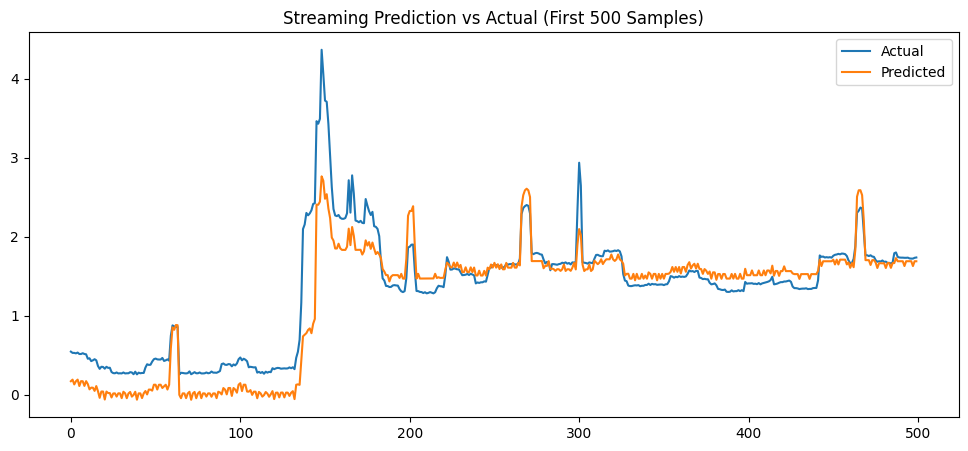

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_stream_true[:500], label="Actual")
plt.plot(y_stream_preds[:500], label="Predicted")
plt.legend()
plt.title("Streaming Prediction vs Actual (First 500 Samples)")
plt.show()


Experiment 1 – Window Size Variation

Code Purpose:
This cell analyzes how different window sizes affect streaming performance.

Explanation:

Smaller windows allow faster adaptation but increase noise.

Larger windows provide smoother predictions but introduce latency.

This experiment demonstrates a core IoT trade-off between responsiveness and stability.

In [21]:
for w in [100, 500, 2000]:
    sgd = SGDRegressor(max_iter=1, eta0=0.001, learning_rate='constant')
    preds = []

    for i in range(0, len(X_test_scaled), w):
        Xw = X_test_scaled[i:i+w]
        yw = y_test.iloc[i:i+w]
        sgd.partial_fit(Xw, yw)
        preds.extend(sgd.predict(Xw))

    rmse = np.sqrt(mean_squared_error(y_test.iloc[:len(preds)], preds))
    print(f"Window Size {w} → RMSE: {rmse:.4f}")


Window Size 100 → RMSE: 0.0582
Window Size 500 → RMSE: 0.0525
Window Size 2000 → RMSE: 0.0472


Experiment 2 – Feature Reduction

Code Purpose:
This cell evaluates the impact of using fewer input features.

Explanation:

Reduced features simulate fewer sensors on an IoT device.

Computational cost decreases, but prediction accuracy may decline.

This reflects real-world design decisions in edge computing systems.

In [22]:
reduced_features = ['Voltage', 'Global_intensity']

Xr_train = scaler.fit_transform(df[reduced_features].iloc[:split_index])
Xr_test  = scaler.transform(df[reduced_features].iloc[split_index:])

sgd = SGDRegressor(max_iter=1, eta0=0.001)
sgd.partial_fit(Xr_train, y_train)

preds = sgd.predict(Xr_test)

print("Reduced Feature RMSE:",
      np.sqrt(mean_squared_error(y_test, preds)))


Reduced Feature RMSE: 0.04807508453556991


Conclusion

This assignment demonstrates that linear regression remains a practical and effective approach for IoT-based predictive analytics, particularly in edge computing environments where computational efficiency and low latency are critical. While offline batch learning achieves higher accuracy, the streaming linear regression model offers real-time adaptability with acceptable performance trade-offs.

The experiments show that window size and feature selection significantly influence model behavior, highlighting important design considerations for real-world IoT deployments. Overall, this work illustrates how simple machine learning models can deliver reliable predictions in streaming data scenarios while remaining lightweight and scalable.